# Detected vs Ground Truth: BIG5-CHAT Evaluation

**Purpose:** Compare Big5Loop's detected OCEAN personality traits with BIG5-CHAT ground truth annotations.

**Comparison logic:**
- Ground truth: `trait` + `level` (high/low) → expected sign (+1 / -1)
- Detected: OCEAN value for target trait → sign matches = agreement

## 1. Setup and load data

In [ ]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

EVAL_DIR = Path(".").resolve()  # Run notebook from evaluation_data/
PROCESSED_DIR = EVAL_DIR / "processed"
RESULTS_PATH = PROCESSED_DIR / "eval_results.jsonl"

TRAIT_TO_OCEAN = {"openness": "O", "conscientiousness": "C", "extraversion": "E", "agreeableness": "A", "neuroticism": "N"}
OCEAN_LABELS = {"O": "Openness", "C": "Conscientiousness", "E": "Extraversion", "A": "Agreeableness", "N": "Neuroticism"}
OCEAN_ORDER = ["O", "C", "E", "A", "N"]

In [10]:
if not RESULTS_PATH.exists():
    raise FileNotFoundError(f"Run: python scripts/run_big5_eval.py --api-only --limit 100\nMissing: {RESULTS_PATH}")

rows = []
with open(RESULTS_PATH) as f:
    for line in f:
        r = json.loads(line)
        if r.get("detected_ocean"):
            rows.append(r)

print(f"Loaded {len(rows)} samples with detected OCEAN")

Loaded 20 samples with detected OCEAN


## 2b. Comparison Table: Detected vs Ground Truth

Side-by-side view of what Big5Loop detected vs what the dataset annotates.

In [ ]:
# Comparison: Ground Truth (expected) vs Detected (target trait)
comparison = df[["trait", "level", "ground_truth", "expected_sign", "detected_target", "agreement"]].copy()
comparison["detected_sign"] = comparison["detected_target"].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
comparison["match"] = comparison["agreement"].map({True: "✓", False: "✗"})
comparison.rename(columns={"expected_sign": "GT (1=high,-1=low)", "detected_target": "Detected"}, inplace=True)
comparison[["trait", "level", "GT (1=high,-1=low)", "Detected", "match"]].head(15)

In [ ]:
# Bar chart: Detected vs Ground Truth (expected) per sample (target trait)
fig, ax = plt.subplots(figsize=(12, 5))
n_show = min(25, len(df))
x = np.arange(n_show)
width = 0.35
ax.bar(x - width/2, df["expected_sign"].head(n_show), width, label="Ground truth", color="lightgray", edgecolor="black")
ax.bar(x + width/2, df["detected_target"].head(n_show), width, label="Detected", color="steelblue", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Sample")
ax.set_ylabel("Value (GT: ±1, Detected: continuous)")
ax.set_title("Detected vs Ground Truth: Target Trait per Sample")
ax.legend()
ax.set_xticks(x)
ax.set_xticklabels([f"{df['trait'].iloc[i][:3]}" for i in range(n_show)], fontsize=8)
plt.tight_layout()
plt.show()

## 2. Build analysis DataFrame

In [12]:
records = []
for r in rows:
    trait = r.get("trait")
    level = r.get("level")
    ocean = r.get("detected_ocean") or {}
    if not trait or not level or trait not in TRAIT_TO_OCEAN:
        continue
    key = TRAIT_TO_OCEAN[trait]
    expected_sign = 1 if level == "high" else -1
    detected_target = float(ocean.get(key, 0))
    detected_sign = 1 if detected_target > 0 else (-1 if detected_target < 0 else 0)
    records.append({
        "trait": trait,
        "level": level,
        "ground_truth": r.get("ground_truth", ""),
        "expected_sign": expected_sign,
        **{f"detected_{k}": float(ocean.get(k, 0)) for k in OCEAN_ORDER},
        "detected_target": detected_target,
        "agreement": detected_sign == expected_sign,
    })

df = pd.DataFrame(records)
df.head(10)

,trait,level,ground_truth,expected_sign,detected_O,detected_C,detected_E,detected_A,detected_N,detected_target,agreement
0,agreeableness,high,agreeableness_high,1,0.2,0.7,0.3,0.8,0.6,0.8,True
1,agreeableness,high,agreeableness_high,1,0.2,0.7,0.8,0.6,0.5,0.6,True
2,agreeableness,high,agreeableness_high,1,0.2,0.7,0.3,0.6,0.5,0.6,True
3,agreeableness,high,agreeableness_high,1,0.4,0.7,0.3,0.6,0.5,0.6,True
4,agreeableness,high,agreeableness_high,1,0.2,0.7,0.6,0.8,0.4,0.8,True
5,agreeableness,high,agreeableness_high,1,0.2,0.7,0.4,0.8,0.6,0.8,True
6,agreeableness,high,agreeableness_high,1,0.2,0.7,0.3,0.6,0.5,0.6,True
7,agreeableness,high,agreeableness_high,1,0.2,0.8,0.3,0.7,-0.6,0.7,True
8,agreeableness,high,agreeableness_high,1,0.2,0.7,0.3,0.6,0.5,0.6,True
9,agreeableness,high,agreeableness_high,1,0.2,0.8,0.1,0.7,0.3,0.7,True


## 3. Detected vs Ground Truth – Scatter

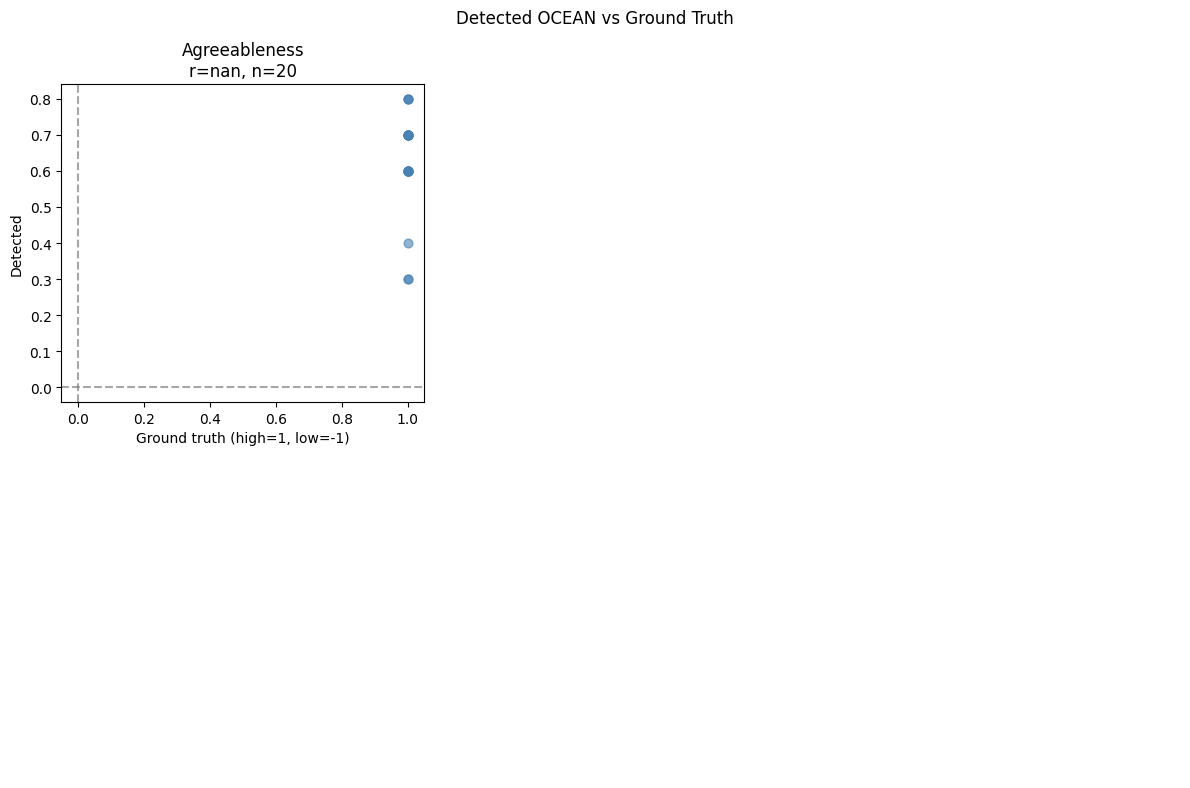

In [13]:
traits = df["trait"].unique()
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, trait in enumerate(traits):
    ax = axes[idx]
    sub = df[df["trait"] == trait]
    x, y = sub["expected_sign"].values, sub["detected_target"].values
    ax.scatter(x, y, alpha=0.6, s=40, c="steelblue")
    ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.7)
    if len(x) >= 3 and np.std(x) > 1e-6:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        ax.plot(np.linspace(x.min(), x.max(), 50), p(np.linspace(x.min(), x.max(), 50)), "r-", lw=2)
    r = np.corrcoef(x, y)[0, 1] if np.std(x) > 1e-6 and np.std(y) > 1e-6 else np.nan
    ax.set_title(f"{OCEAN_LABELS[TRAIT_TO_OCEAN[trait]]}\nr={r:.3f}, n={len(sub)}")
    ax.set_xlabel("Ground truth (high=1, low=-1)")
    ax.set_ylabel("Detected")

for j in range(len(traits), len(axes)):
    axes[j].axis("off")
plt.suptitle("Detected OCEAN vs Ground Truth")
plt.tight_layout()
plt.show()

## 4. OCEAN Heatmap

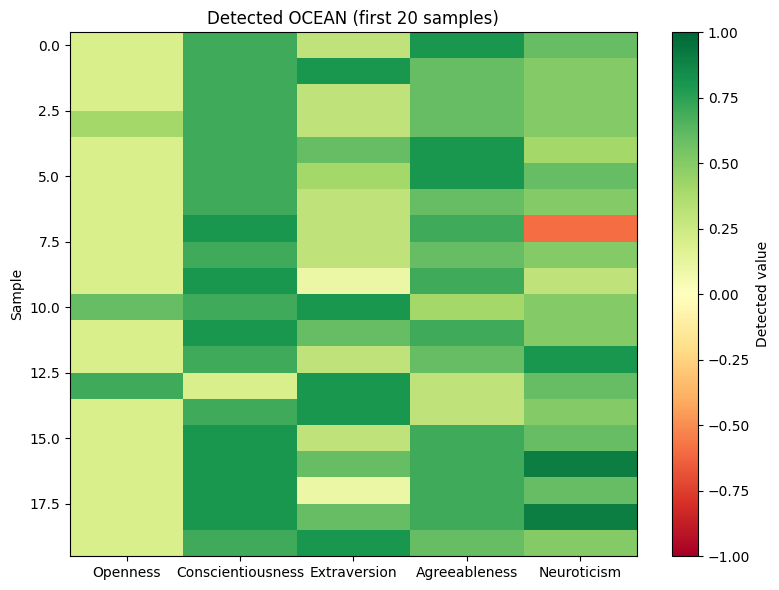

In [14]:
n_show = min(50, len(df))
mat = df.head(n_show)[[f"detected_{k}" for k in OCEAN_ORDER]].values
fig, ax = plt.subplots(figsize=(8, max(6, n_show * 0.15)))
im = ax.imshow(mat, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(5))
ax.set_xticklabels([OCEAN_LABELS[k] for k in OCEAN_ORDER])
ax.set_ylabel("Sample")
ax.set_title(f"Detected OCEAN (first {n_show} samples)")
plt.colorbar(im, ax=ax, label="Detected value")
plt.tight_layout()
plt.show()

## 5. Distribution by Ground Truth Level

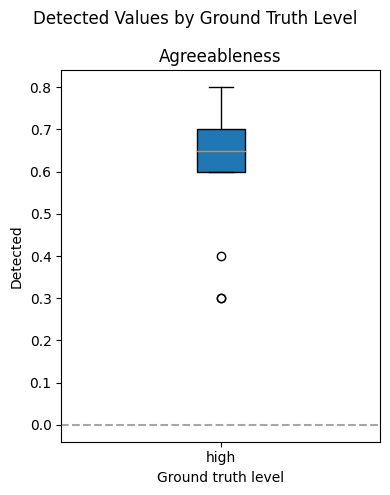

In [15]:
fig, axes = plt.subplots(1, min(len(traits), 5), figsize=(4 * len(traits), 5))
if len(traits) == 1:
    axes = [axes]
for idx, trait in enumerate(traits[:5]):
    ax = axes[idx]
    sub = df[df["trait"] == trait]
    levels = sorted(sub["level"].unique(), reverse=True)
    data = [sub[sub["level"] == lv]["detected_target"].values for lv in levels]
    ax.boxplot(data, labels=levels, patch_artist=True)
    ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax.set_ylabel("Detected")
    ax.set_xlabel("Ground truth level")
    ax.set_title(OCEAN_LABELS[TRAIT_TO_OCEAN[trait]])
plt.suptitle("Detected Values by Ground Truth Level")
plt.tight_layout()
plt.show()

## 6. Metrics Summary

In [16]:
metrics = []
for trait in traits:
    sub = df[df["trait"] == trait]
    x, y = sub["expected_sign"].values, sub["detected_target"].values
    agree = sub["agreement"].sum()
    total = len(sub)
    r = np.corrcoef(x, y)[0, 1] if np.std(x) > 1e-6 and np.std(y) > 1e-6 else np.nan
    mae = np.mean(np.abs(y - x))
    metrics.append({
        "Trait": OCEAN_LABELS[TRAIT_TO_OCEAN[trait]],
        "n": total,
        "Agreement %": f"{agree/total*100:.1f}" if total > 0 else "—",
        "Pearson r": f"{r:.3f}" if not np.isnan(r) else "N/A",
        "MAE": f"{mae:.3f}",
    })

pd.DataFrame(metrics)

,Trait,n,Agreement %,Pearson r,MAE
0,Agreeableness,20,100.0,N/A,0.375


## 7. Export summary

In [ ]:
out_path = PROCESSED_DIR / "eval_summary.csv"
df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

Saved: /Users/huaduojiejia/MyProject/hslu/2026/thesis project/Big5Loop/evaluation_data/processed/eval_summary.csv
